# Florida outage recovery persistence baseline

This notebook builds a one-step persistence baseline for the Florida storm-associated outage events.

It uses the hourly ERA5 event file in `data_transients`, pulls only the needed outage rows from `timeseries.pq`, and evaluates:

$\hat{y}_t = y_{t-1}$

where `y` is `outageFraction`.

The output is a merged event-hour table, event-level and overall error metrics, and a few comparison plots.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

In [2]:
def find_repo_root():
    here = Path.cwd().resolve()
    candidates = [here, *here.parents, Path(r"C:\Users\teaching\Downloads\outage-recovery-forecasting")]
    for candidate in candidates:
        raw = candidate / "data_raw" / "timeseries.pq"
        transients = candidate / "data_transients"
        if raw.exists() and transients.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find the repo root. Expected data_raw/timeseries.pq and data_transients/."
    )

def pick_file(folder: Path, patterns):
    matches = []
    for pattern in patterns:
        matches.extend(folder.glob(pattern))
    matches = [p.resolve() for p in matches if p.is_file()]
    if not matches:
        raise FileNotFoundError(f"No files matched {patterns} in {folder}")
    matches = sorted(set(matches), key=lambda p: p.stat().st_mtime, reverse=True)
    return matches[0]

REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / "data_raw"
TRANSIENTS_DIR = REPO_ROOT / "data_transients"
TS_PATH = RAW_DIR / "timeseries.pq"
WEATHER_PATH = pick_file(TRANSIENTS_DIR, ["*era5*hourly*.csv", "*weather*.csv"])
FL_POUS_PATH = TRANSIENTS_DIR / "FL_POUS.csv"

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"TS_PATH: {TS_PATH}")
print(f"WEATHER_PATH: {WEATHER_PATH}")
print(f"FL_POUS_PATH exists: {FL_POUS_PATH.exists()}")

REPO_ROOT: C:\Users\teaching\Downloads\outage-recovery-forecasting
TS_PATH: C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\timeseries.pq
WEATHER_PATH: C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_all_events_era5_hourly.csv
FL_POUS_PATH exists: True


In [3]:
weather = pd.read_csv(
    WEATHER_PATH,
    dtype={
        "event_id": "string",
        "storm": "string",
        "geoid": "string",
        "county": "string",
    },
)

weather["event_id"] = weather["event_id"].astype("string")
weather["storm"] = weather["storm"].astype("string")
weather["geoid"] = weather["geoid"].astype("string").str.zfill(5)
weather["datetime"] = pd.to_datetime(weather["datetime"], errors="coerce").dt.floor("h")
weather["event_start"] = pd.to_datetime(weather["event_start"], errors="coerce")
weather["duration_hours"] = pd.to_numeric(weather["duration_hours"], errors="coerce")

weather = weather.dropna(subset=["event_id", "geoid", "datetime"]).sort_values(
    ["event_id", "geoid", "datetime"]
).reset_index(drop=True)

event_master = (
    weather[["event_id", "storm", "geoid", "event_start", "duration_hours"]]
    .drop_duplicates()
    .rename(columns={"geoid": "CountyFIPS"})
    .sort_values(["event_start", "event_id"])
    .reset_index(drop=True)
)

print(f"Weather rows: {len(weather):,}")
print(f"Event count from weather file: {len(event_master):,}")
display(event_master.head(10))

if FL_POUS_PATH.exists():
    fl_pous = pd.read_csv(FL_POUS_PATH, dtype={"CountyFIPS": "string", "storm": "string"})
    fl_pous["CountyFIPS"] = fl_pous["CountyFIPS"].astype("string").str.zfill(5)
    fl_pous["event_start"] = pd.to_datetime(fl_pous["event_start"], errors="coerce")
    print(f"FL_POUS rows: {len(fl_pous):,}")
    print(f"Unique FL counties: {fl_pous['CountyFIPS'].nunique():,}")

Weather rows: 17,510
Event count from weather file: 99


,event_id,storm,CountyFIPS,event_start,duration_hours
0,12075_2017-07-30 21:00:00,2017212N28275,12075,2017-07-30 21:00:00,86
1,12037_2017-09-09 19:00:00,2017242N16333,12037,2017-09-09 19:00:00,122
2,12059_2017-09-09 20:00:00,2017242N16333,12059,2017-09-09 20:00:00,43
3,12067_2017-09-09 20:00:00,2017242N16333,12067,2017-09-09 20:00:00,191
4,12013_2017-09-09 21:00:00,2017242N16333,12013,2017-09-09 21:00:00,54
5,12075_2017-09-09 22:00:00,2017242N16333,12075,2017-09-09 22:00:00,190
6,12079_2017-09-10 02:00:00,2017242N16333,12079,2017-09-10 02:00:00,124
7,12011_2017-09-10 06:00:00,2017242N16333,12011,2017-09-10 06:00:00,178
8,12086_2017-09-10 06:00:00,2017242N16333,12086,2017-09-10 06:00:00,210
9,12125_2017-09-10 11:00:00,2017242N16333,12125,2017-09-10 11:00:00,133


FL_POUS rows: 99
Unique FL counties: 64


In [4]:
OUTAGE_DATASET = ds.dataset(TS_PATH, format="parquet")

def load_outage_window(dataset, county_fips, window_start, window_end):
    county_fips = str(county_fips).zfill(5)

    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= window_start) &
        (ds.field("RecordDateTime") <= window_end)
    )

    table = dataset.to_table(
        filter=filt,
        columns=["RecordDateTime", "CountyFIPS", "OutageFraction", "CustomersTracked"],
    )

    df = table.to_pandas()
    if "RecordDateTime" not in df.columns or "CountyFIPS" not in df.columns:
        df = df.reset_index()

    rename_map = {}
    if "RecordDateTime" in df.columns:
        rename_map["RecordDateTime"] = "datetime"
    if "OutageFraction" in df.columns:
        rename_map["OutageFraction"] = "outageFraction"
    if "CustomersTracked" in df.columns:
        rename_map["CustomersTracked"] = "customersTracked"

    df = df.rename(columns=rename_map)

    if "CountyFIPS" not in df.columns or "datetime" not in df.columns:
        raise KeyError(f"Missing expected columns after loading outage window. Columns: {df.columns.tolist()}")

    df["CountyFIPS"] = df["CountyFIPS"].astype("string").str.zfill(5)
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce").dt.floor("h")

    return df[["datetime", "CountyFIPS", "outageFraction", "customersTracked"]].sort_values("datetime").reset_index(drop=True)

def merge_outage_weather(outage_df, weather_df, event_row):
    event_id = str(event_row["event_id"])
    county_fips = str(event_row["CountyFIPS"]).zfill(5)

    w = weather_df.copy()
    w["event_id"] = w["event_id"].astype("string")
    w["geoid"] = w["geoid"].astype("string").str.zfill(5)
    w["datetime"] = pd.to_datetime(w["datetime"], errors="coerce").dt.floor("h")

    w = w[(w["event_id"] == event_id) & (w["geoid"] == county_fips)].copy()
    if w.empty:
        return pd.DataFrame()

    o = outage_df.copy()
    o["CountyFIPS"] = o["CountyFIPS"].astype("string").str.zfill(5)
    o["datetime"] = pd.to_datetime(o["datetime"], errors="coerce").dt.floor("h")
    o = o[["CountyFIPS", "datetime", "outageFraction", "customersTracked"]]

    merged = w.merge(
        o,
        left_on=["geoid", "datetime"],
        right_on=["CountyFIPS", "datetime"],
        how="left",
        suffixes=("", "_outage"),
    )

    merged["event_start"] = pd.to_datetime(merged["event_start"], errors="coerce")
    merged["duration_hours"] = pd.to_numeric(merged["duration_hours"], errors="coerce")
    merged = merged.sort_values("datetime").reset_index(drop=True)

    keep_cols = [
        "event_id", "storm", "geoid", "county", "datetime",
        "event_start", "duration_hours",
        "gust_mps", "wind_speed_mps", "precip_mm", "pressure_hpa", "temp_c",
        "CountyFIPS", "outageFraction", "customersTracked",
    ]
    keep_cols = [c for c in keep_cols if c in merged.columns]
    return merged[keep_cols]

def compute_persistence_baseline(df):
    out = df.copy()
    out = out.sort_values(["event_id", "geoid", "datetime"]).reset_index(drop=True)
    out["persistence_1h"] = out.groupby(["event_id", "geoid"])["outageFraction"].shift(1)
    out["error"] = out["outageFraction"] - out["persistence_1h"]
    out["abs_error"] = out["error"].abs()
    out["sq_error"] = out["error"] ** 2
    return out

def regression_metrics(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    valid = y_true.notna() & y_pred.notna()
    y_true = y_true[valid]
    y_pred = y_pred[valid]
    if len(y_true) == 0:
        return {"n": 0, "mae": np.nan, "rmse": np.nan}
    err = y_true - y_pred
    return {
        "n": int(len(y_true)),
        "mae": float(np.mean(np.abs(err))),
        "rmse": float(np.sqrt(np.mean(err ** 2))),
    }

In [5]:
coverage_rows = []
event_tables = []

for row in event_master.to_dict("records"):
    county_fips = str(row["CountyFIPS"]).zfill(5)
    event_start = pd.to_datetime(row["event_start"], errors="coerce")

    duration_hours = row.get("duration_hours")
    if pd.isna(duration_hours) or float(duration_hours) <= 0:
        duration_hours = 24.0
    else:
        duration_hours = float(duration_hours)

    window_start = event_start - pd.Timedelta(hours=12)
    window_end = event_start + pd.Timedelta(hours=max(duration_hours, 24.0) + 12)

    outage = load_outage_window(OUTAGE_DATASET, county_fips, window_start, window_end)
    merged = merge_outage_weather(outage, weather, row)

    coverage_rows.append({
        "event_id": str(row["event_id"]),
        "CountyFIPS": county_fips,
        "storm": str(row["storm"]),
        "event_start": event_start,
        "duration_hours": duration_hours,
        "outage_rows": int(len(outage)),
        "merged_rows": int(len(merged)),
        "outage_rows_with_observation": int(merged["outageFraction"].notna().sum()) if not merged.empty else 0,
        "has_weather_rows": bool(len(merged) > 0),
    })

    if not merged.empty:
        event_tables.append(merged)

coverage_df = pd.DataFrame(coverage_rows).sort_values(["event_start", "event_id"]).reset_index(drop=True)

if event_tables:
    model_df = pd.concat(event_tables, ignore_index=True)
else:
    model_df = pd.DataFrame()

print(f"Events processed: {len(coverage_df):,}")
display(coverage_df.head(15))
print("Coverage totals:")
display(coverage_df[["outage_rows", "merged_rows", "outage_rows_with_observation"]].describe())

Events processed: 99


,event_id,CountyFIPS,storm,event_start,duration_hours,outage_rows,merged_rows,outage_rows_with_observation,has_weather_rows
0,12075_2017-07-30 21:00:00,12075,2017212N28275,2017-07-30 21:00:00,86.0,111,110,110,True
1,12037_2017-09-09 19:00:00,12037,2017242N16333,2017-09-09 19:00:00,122.0,147,146,146,True
2,12059_2017-09-09 20:00:00,12059,2017242N16333,2017-09-09 20:00:00,43.0,68,67,67,True
3,12067_2017-09-09 20:00:00,12067,2017242N16333,2017-09-09 20:00:00,191.0,216,215,215,True
4,12013_2017-09-09 21:00:00,12013,2017242N16333,2017-09-09 21:00:00,54.0,79,78,78,True
5,12075_2017-09-09 22:00:00,12075,2017242N16333,2017-09-09 22:00:00,190.0,215,214,214,True
6,12079_2017-09-10 02:00:00,12079,2017242N16333,2017-09-10 02:00:00,124.0,149,148,148,True
7,12011_2017-09-10 06:00:00,12011,2017242N16333,2017-09-10 06:00:00,178.0,203,202,202,True
8,12086_2017-09-10 06:00:00,12086,2017242N16333,2017-09-10 06:00:00,210.0,235,234,234,True
9,12125_2017-09-10 11:00:00,12125,2017242N16333,2017-09-10 11:00:00,133.0,158,157,157,True


Coverage totals:


,outage_rows,merged_rows,outage_rows_with_observation
count,99.000000,99.000000,99.000000
mean,177.868687,176.868687,176.868687
std,110.021857,110.021857,110.021857
min,50.000000,49.000000,49.000000
25%,86.000000,85.000000,85.000000
50%,172.000000,171.000000,171.000000
75%,215.500000,214.500000,214.500000
max,578.000000,577.000000,577.000000


In [6]:
if model_df.empty:
    raise RuntimeError("No merged event-hour data were created.")

model_df = compute_persistence_baseline(model_df)

eval_df = model_df.dropna(subset=["outageFraction", "persistence_1h"]).copy()

overall_metrics = regression_metrics(eval_df["outageFraction"], eval_df["persistence_1h"])
overall_metrics_df = pd.DataFrame([overall_metrics])

event_metrics = (
    eval_df.groupby(["event_id", "CountyFIPS", "storm"], dropna=False)
    .apply(lambda g: pd.Series(regression_metrics(g["outageFraction"], g["persistence_1h"])))
    .reset_index()
    .sort_values(["mae", "rmse", "event_id"])
    .reset_index(drop=True)
)

print("Overall persistence metrics:")
display(overall_metrics_df)

print("Event-level persistence metrics (sorted by MAE):")
display(event_metrics.head(20))

print(f"Evaluation rows used: {len(eval_df):,}")

Overall persistence metrics:


C:\Users\teaching\AppData\Local\Temp\ipykernel_49168\3634940054.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series(regression_metrics(g["outageFraction"], g["persistence_1h"])))


,n,mae,rmse
0,17411,0.020125,0.072269


Event-level persistence metrics (sorted by MAE):


,event_id,CountyFIPS,storm,n,mae,rmse
0,12063_2018-06-02 20:00:00,12063,2018146N19273,51.0,0.005041,0.012444
1,12045_2018-10-10 15:00:00,12045,2018280N18273,537.0,0.005372,0.027408
2,12049_2018-09-09 01:00:00,12049,2018246N22283,49.0,0.006028,0.019961
3,12063_2017-09-15 17:00:00,12063,2017242N16333,58.0,0.006434,0.018438
4,12077_2018-10-10 13:00:00,12077,2018280N18273,411.0,0.006436,0.029513
5,12043_2017-09-11 22:00:00,12043,2017242N16333,261.0,0.006539,0.024024
6,12133_2018-10-10 18:00:00,12133,2018280N18273,436.0,0.007198,0.028161
7,12005_2018-10-10 17:00:00,12005,2018280N18273,527.0,0.007452,0.035733
8,12109_2022-09-29 08:00:00,12109,2022263N10313,61.0,0.007502,0.012420
9,12013_2018-10-10 18:00:00,12013,2018280N18273,534.0,0.007511,0.043732


Evaluation rows used: 17,411


Plotting 4 events: ['12063_2018-10-09 00:00:00', '12045_2018-10-10 15:00:00', '12013_2018-10-10 18:00:00', '12005_2018-10-10 17:00:00']


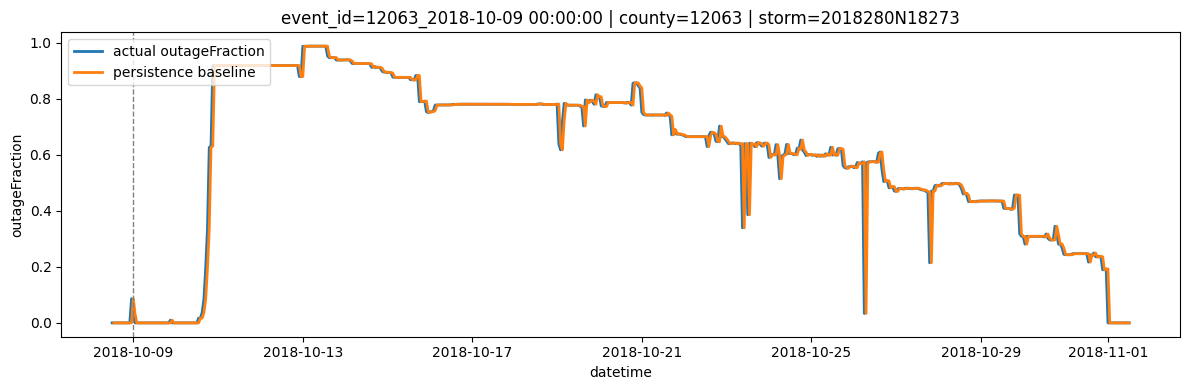

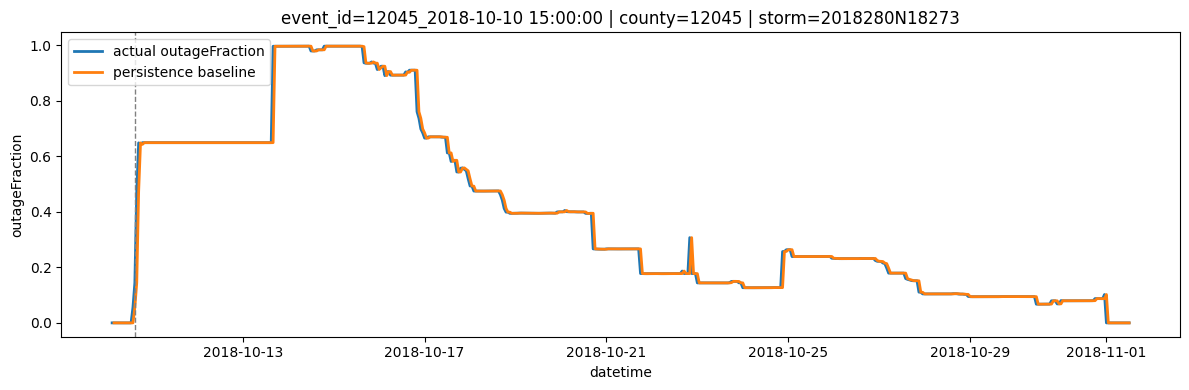

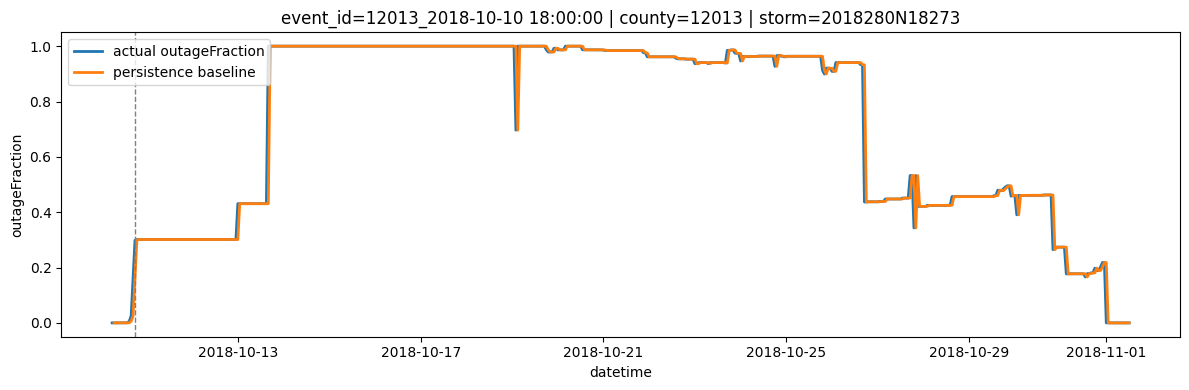

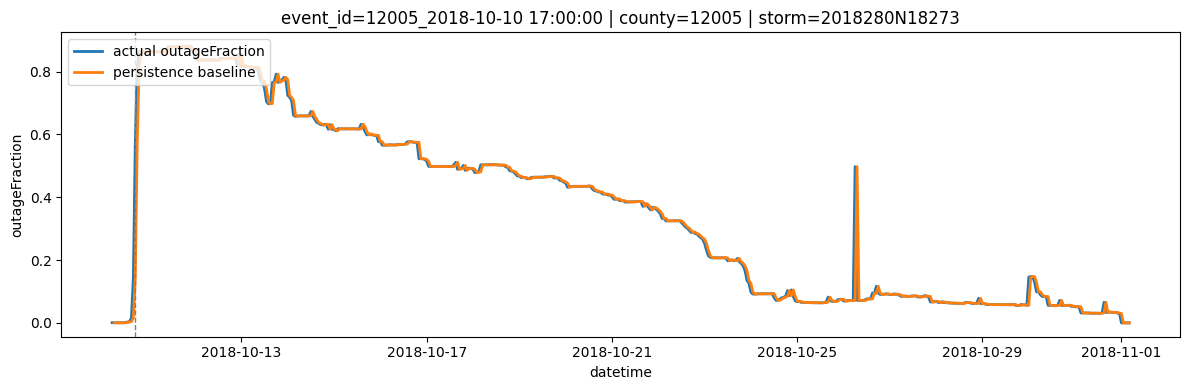

In [7]:
def plot_event_persistence(df, title):
    df = df.sort_values("datetime").copy()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df["datetime"], df["outageFraction"], label="actual outageFraction", linewidth=2)
    ax.plot(df["datetime"], df["persistence_1h"], label="persistence baseline", linewidth=2)
    ax.axvline(pd.to_datetime(df["event_start"].iloc[0]), linestyle="--", linewidth=1, color="gray")

    ax.set_title(title)
    ax.set_xlabel("datetime")
    ax.set_ylabel("outageFraction")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

sample_events = (
    coverage_df.sort_values(["merged_rows", "event_start"], ascending=[False, True])
    .head(4)["event_id"]
    .tolist()
)

print(f"Plotting {len(sample_events)} events: {sample_events}")

for event_id in sample_events:
    sub = model_df[model_df["event_id"] == event_id].copy()
    if sub.empty:
        continue
    sub = sub.dropna(subset=["outageFraction"]).copy()
    if sub.empty:
        continue

    row = event_master[event_master["event_id"] == event_id].iloc[0]
    title = f"event_id={event_id} | county={row['CountyFIPS']} | storm={row['storm']}"
    plot_event_persistence(sub, title)

In [8]:
out_dir = TRANSIENTS_DIR
model_path = out_dir / "florida_event_hourly_model_table.parquet"
metrics_path = out_dir / "persistence_baseline_event_metrics.csv"
coverage_path = out_dir / "persistence_baseline_coverage.csv"

model_df.to_parquet(model_path, index=False)
event_metrics.to_csv(metrics_path, index=False)
coverage_df.to_csv(coverage_path, index=False)

print(f"Saved model table: {model_path}")
print(f"Saved metrics: {metrics_path}")
print(f"Saved coverage: {coverage_path}")

Saved model table: C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_event_hourly_model_table.parquet
Saved metrics: C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\persistence_baseline_event_metrics.csv
Saved coverage: C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\persistence_baseline_coverage.csv


So, the above worked quite well for one-step persistence, but the real task is in **multi-step prediction**

In [19]:
FORECAST_HORIZONS = [24, 48, 72]

def compute_multi_step_persistence(df, horizons=FORECAST_HORIZONS):
    out = df.copy()
    out = out.sort_values(["event_id", "geoid", "datetime"]).reset_index(drop=True)

    for h in horizons:
        col = f"persistence_{h}h"
        out[col] = out.groupby(["event_id", "geoid"])["outageFraction"].shift(h)

    return out

model_df = compute_multi_step_persistence(model_df)

In [20]:
multi_metrics_rows = []
multi_event_metrics_rows = []

for h in FORECAST_HORIZONS:
    pred_col = f"persistence_{h}h"
    eval_h = model_df.dropna(subset=["outageFraction", pred_col]).copy()

    overall = regression_metrics(eval_h["outageFraction"], eval_h[pred_col])
    overall["horizon_hours"] = h
    multi_metrics_rows.append(overall)

    event_metrics_h = (
        eval_h.groupby(["event_id", "CountyFIPS", "storm"], dropna=False)
        .apply(lambda g: pd.Series(regression_metrics(g["outageFraction"], g[pred_col])))
        .reset_index()
    )
    event_metrics_h["horizon_hours"] = h
    multi_event_metrics_rows.append(event_metrics_h)

multi_metrics_df = (
    pd.DataFrame(multi_metrics_rows)
    .sort_values("horizon_hours")
    .reset_index(drop=True)
)

multi_event_metrics_df = (
    pd.concat(multi_event_metrics_rows, ignore_index=True)
    .sort_values(["horizon_hours", "mae", "rmse", "event_id"])
    .reset_index(drop=True)
)

print("Overall multi-step persistence metrics:")
display(multi_metrics_df)

print("Event-level multi-step persistence metrics:")
display(multi_event_metrics_df.head(30))

C:\Users\teaching\AppData\Local\Temp\ipykernel_49168\2498022572.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series(regression_metrics(g["outageFraction"], g[pred_col])))
C:\Users\teaching\AppData\Local\Temp\ipykernel_49168\2498022572.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series(regression_metrics(g["outageFraction"], g[pred_col])))


Overall multi-step persistence metrics:


C:\Users\teaching\AppData\Local\Temp\ipykernel_49168\2498022572.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series(regression_metrics(g["outageFraction"], g[pred_col])))


,n,mae,rmse,horizon_hours
0,15134,0.158280,0.251203,24
1,12758,0.235931,0.309376,48
2,10640,0.295824,0.358309,72


Event-level multi-step persistence metrics:


,event_id,CountyFIPS,storm,n,mae,rmse,horizon_hours
0,12063_2018-06-02 20:00:00,12063,2018146N19273,28.0,0.007573,0.016865,24
1,12049_2018-09-09 01:00:00,12049,2018246N22283,26.0,0.007854,0.022428,24
2,12063_2017-09-15 17:00:00,12063,2017242N16333,35.0,0.008454,0.021958,24
3,12051_2021-07-04 07:00:00,12051,2021182N09317,39.0,0.010609,0.037393,24
4,12013_2020-09-12 22:00:00,12013,2020256N25281,112.0,0.023207,0.047046,24
5,12029_2021-07-06 00:00:00,12029,2021182N09317,46.0,0.035683,0.080010,24
6,12059_2017-09-09 20:00:00,12059,2017242N16333,43.0,0.039617,0.123087,24
7,12065_2021-09-09 07:00:00,12065,2021252N28273,25.0,0.053979,0.080482,24
8,12133_2017-09-10 16:00:00,12133,2017242N16333,30.0,0.057265,0.177994,24
9,12075_2017-07-30 21:00:00,12075,2017212N28275,86.0,0.058793,0.225326,24


Plotting 4 events: ['12063_2018-10-09 00:00:00', '12045_2018-10-10 15:00:00', '12013_2018-10-10 18:00:00', '12005_2018-10-10 17:00:00']

=== 24h persistence ===


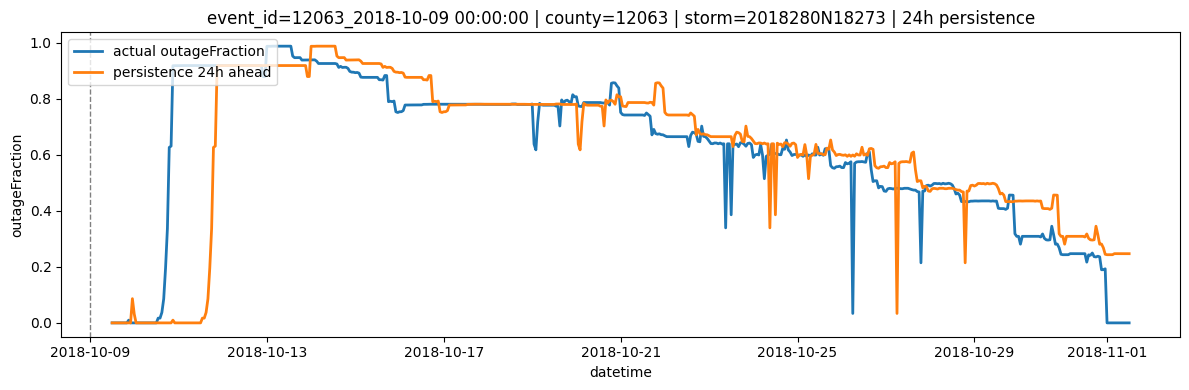

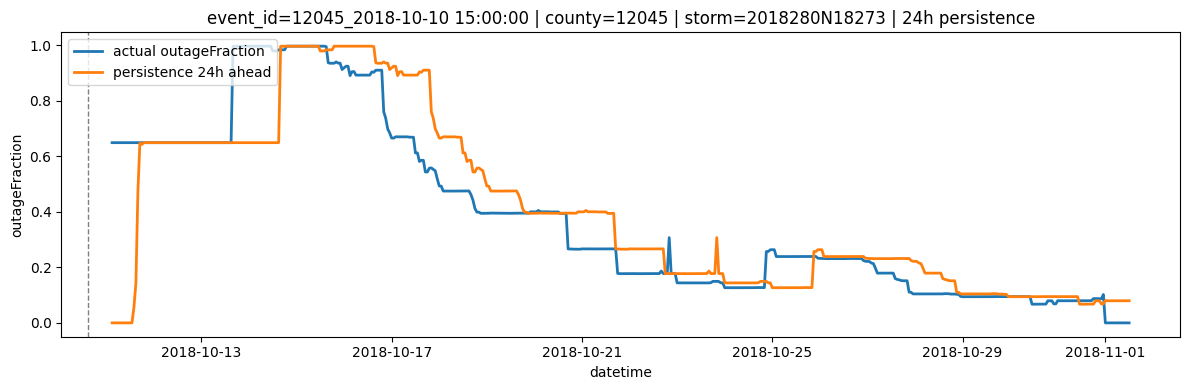

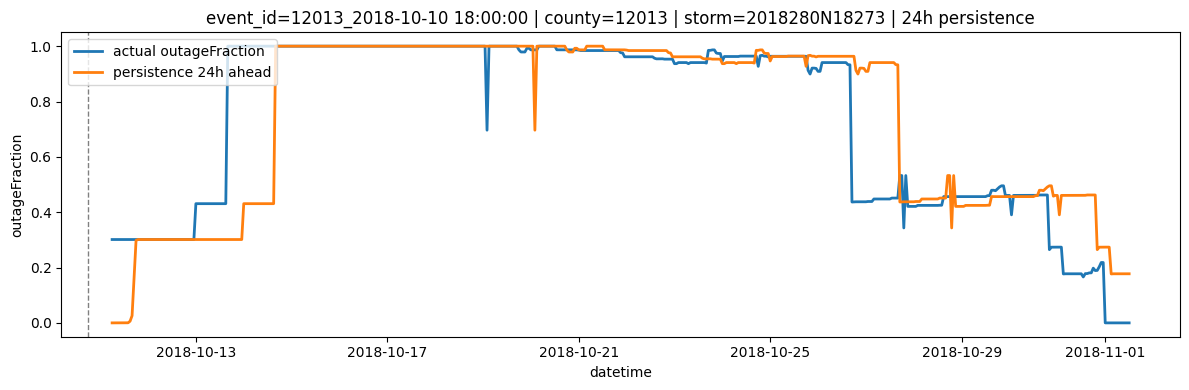

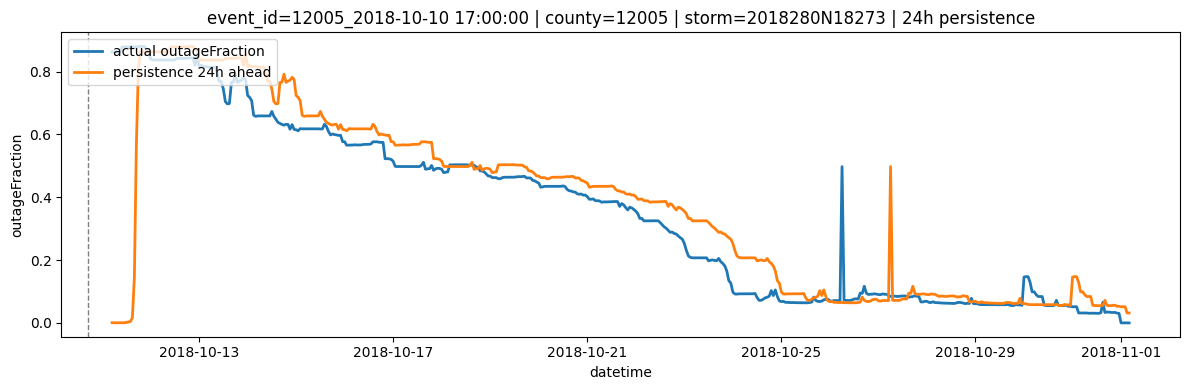


=== 48h persistence ===


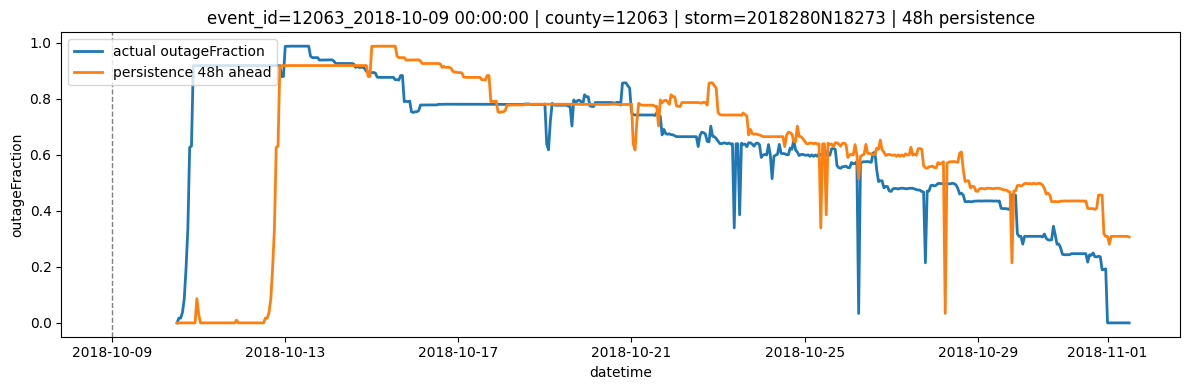

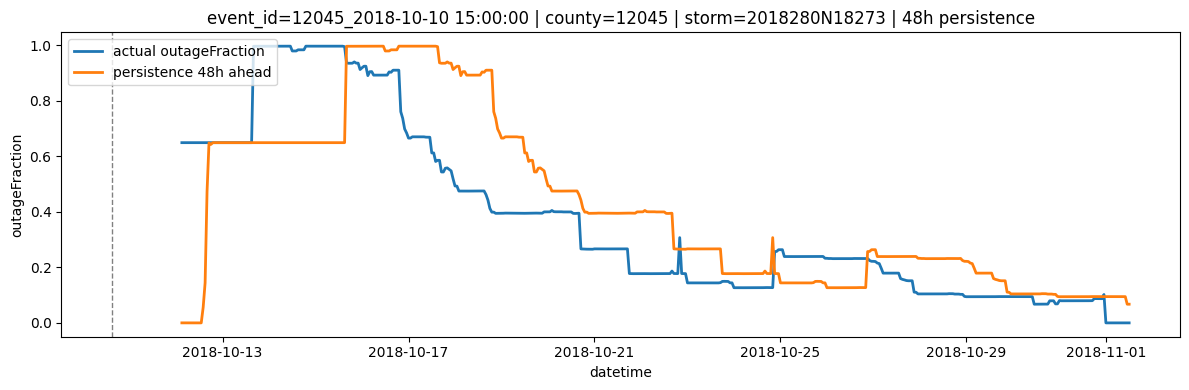

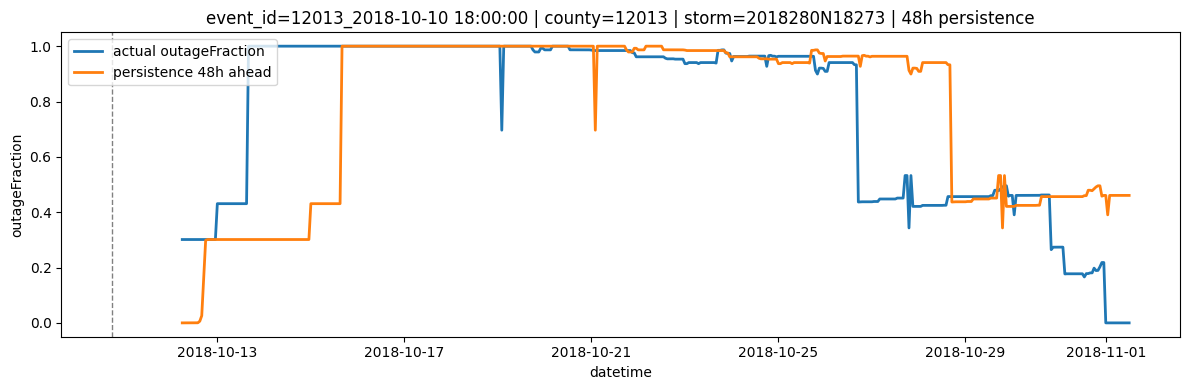

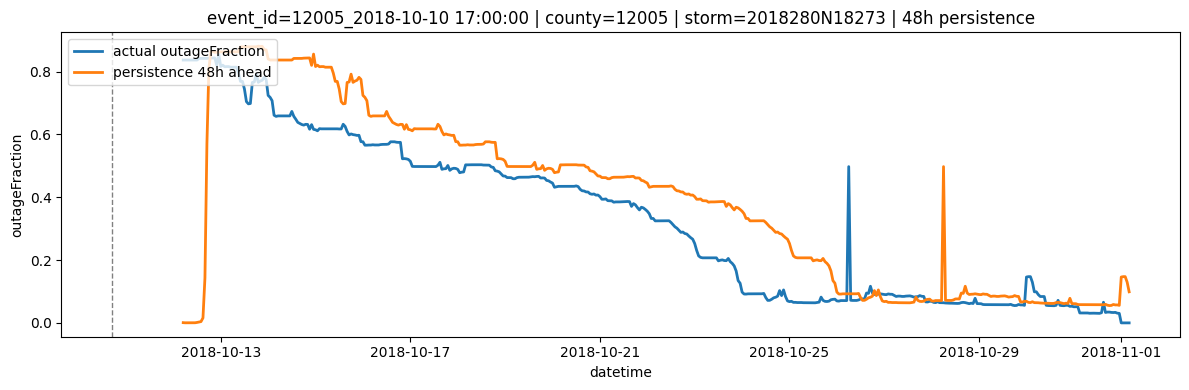


=== 72h persistence ===


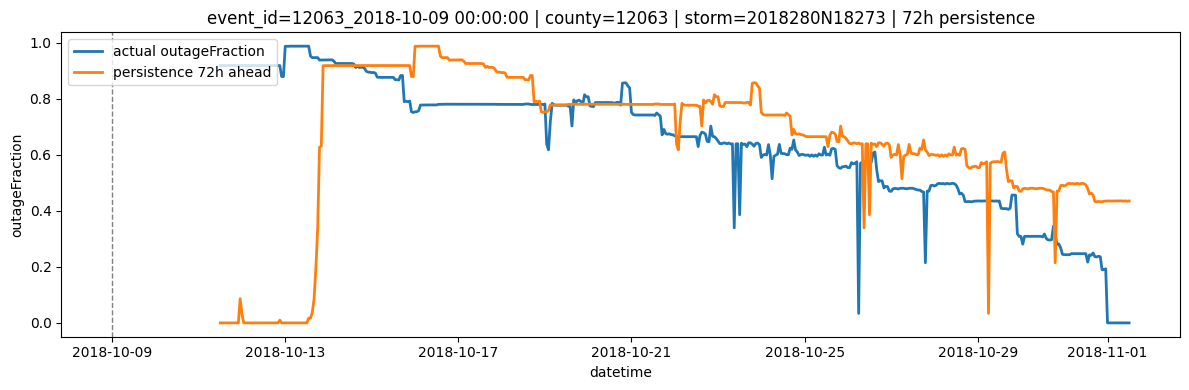

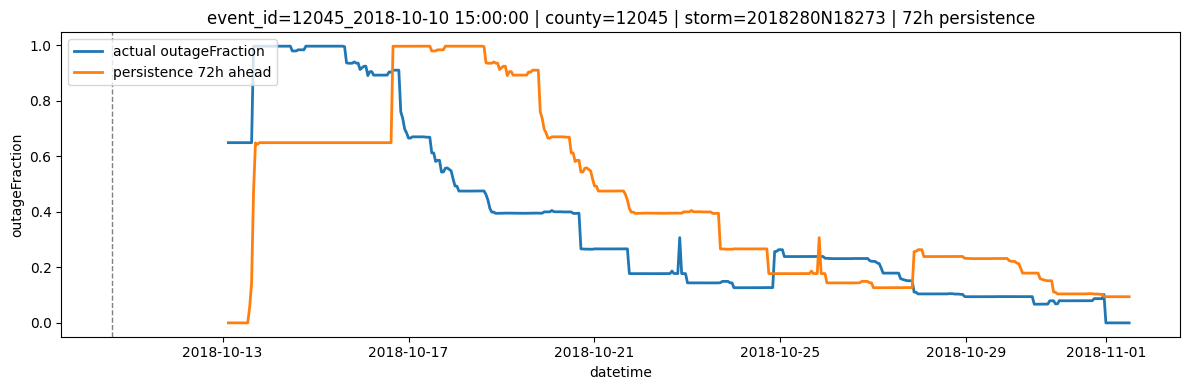

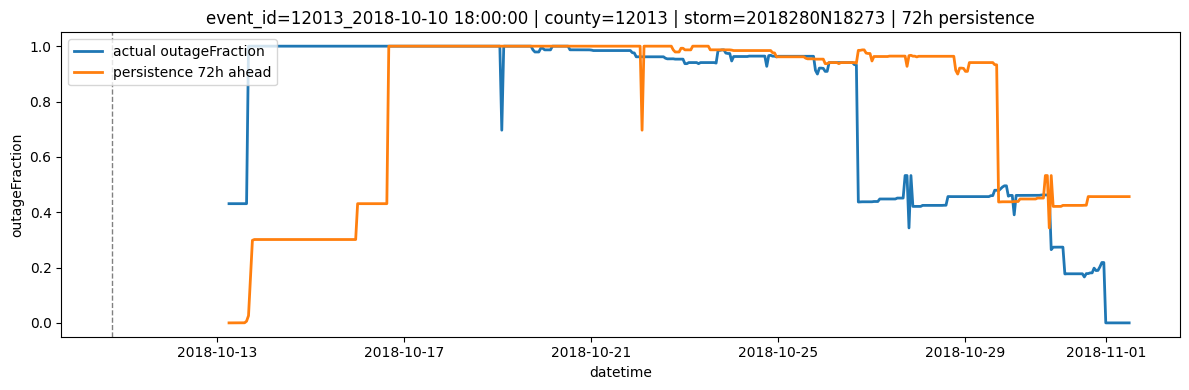

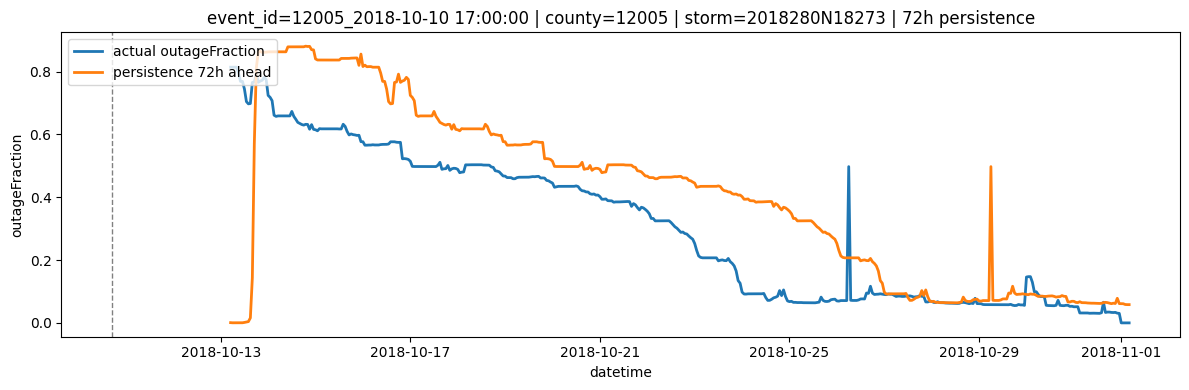

In [21]:
def plot_event_persistence_horizon(df, title, horizon_hours):
    pred_col = f"persistence_{horizon_hours}h"

    df = df.sort_values("datetime").copy()
    df = df.dropna(subset=["outageFraction", pred_col]).copy()

    if df.empty:
        print(f"No valid rows for {title} at {horizon_hours}h horizon.")
        return

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df["datetime"], df["outageFraction"], label="actual outageFraction", linewidth=2)
    ax.plot(df["datetime"], df[pred_col], label=f"persistence {horizon_hours}h ahead", linewidth=2)
    ax.axvline(pd.to_datetime(df["event_start"].iloc[0]), linestyle="--", linewidth=1, color="gray")

    ax.set_title(f"{title} | {horizon_hours}h persistence")
    ax.set_xlabel("datetime")
    ax.set_ylabel("outageFraction")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


print(f"Plotting {len(sample_events)} events: {sample_events}")

for horizon_hours in FORECAST_HORIZONS:
    print(f"\n=== {horizon_hours}h persistence ===")
    for event_id in sample_events:
        sub = model_df[model_df["event_id"] == event_id].copy()
        if sub.empty:
            continue

        row = event_master[event_master["event_id"] == event_id].iloc[0]
        title = f"event_id={event_id} | county={row['CountyFIPS']} | storm={row['storm']}"
        plot_event_persistence_horizon(sub, title, horizon_hours)

^ not bad, though i don't like how it's not making any prediction for the first X hours

I will be moving to a different chat window to do the first tft model, but i want to retain all that you have learned, esp so that we can compare these baselines to the tft. So, given all that you've done so far, write enough technical context (including var names, stored df's, etc) so that it can continue. and advise if it makes sense to do this in another notebook or if the other notebook won't be able to call upon the data from another notebook.

In [22]:
sample_event_metrics = multi_event_metrics_df[
    multi_event_metrics_df["event_id"].isin(sample_events)
].copy()

print("Sample-event multi-step persistence metrics:")
display(sample_event_metrics.sort_values(["event_id", "horizon_hours"]))

Sample-event multi-step persistence metrics:


,event_id,CountyFIPS,storm,n,mae,rmse,horizon_hours
13,12005_2018-10-10 17:00:00,12005,2018280N18273,504.0,0.067879,0.148339,24
120,12005_2018-10-10 17:00:00,12005,2018280N18273,480.0,0.108540,0.172653,48
209,12005_2018-10-10 17:00:00,12005,2018280N18273,456.0,0.146397,0.199468,72
19,12013_2018-10-10 18:00:00,12013,2018280N18273,511.0,0.091060,0.191052,24
133,12013_2018-10-10 18:00:00,12013,2018280N18273,487.0,0.164257,0.284681,48
219,12013_2018-10-10 18:00:00,12013,2018280N18273,463.0,0.230563,0.354977,72
17,12045_2018-10-10 15:00:00,12045,2018280N18273,514.0,0.089553,0.154323,24
130,12045_2018-10-10 15:00:00,12045,2018280N18273,490.0,0.162402,0.218759,48
218,12045_2018-10-10 15:00:00,12045,2018280N18273,466.0,0.226792,0.276620,72
18,12063_2018-10-09 00:00:00,12063,2018280N18273,553.0,0.090262,0.200155,24


Updating it so that it can do forecasts for the first N hours:

In [23]:
FORECAST_HORIZONS = [24, 48, 72]

def build_operational_persistence_forecasts(
    df,
    horizons=FORECAST_HORIZONS,
    id_cols=("event_id", "CountyFIPS"),
    time_col="datetime",
    y_col="outageFraction",
    event_start_col="event_start",
):
    d = df.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce").dt.floor("h")
    d[event_start_col] = pd.to_datetime(d[event_start_col], errors="coerce")
    d = d.dropna(subset=[*id_cols, time_col, y_col, event_start_col]).sort_values(list(id_cols) + [time_col])

    all_rows = []

    for _, g in d.groupby(list(id_cols), sort=False):
        g = g.sort_values(time_col).copy()
        g = g.drop_duplicates(subset=[time_col])

        event_id = g["event_id"].iloc[0]
        county_fips = g["CountyFIPS"].iloc[0]
        storm = g["storm"].iloc[0] if "storm" in g.columns else None
        event_start = g[event_start_col].iloc[0]

        origin_candidates = g[g[time_col] >= event_start].copy()
        if origin_candidates.empty:
            continue

        origin_row = origin_candidates.iloc[0]
        origin_datetime = origin_row[time_col]
        origin_value = float(origin_row[y_col])

        for h in horizons:
            horizon_end = origin_datetime + pd.Timedelta(hours=h)

            future = g[
                (g[time_col] > origin_datetime) &
                (g[time_col] <= horizon_end)
            ][[time_col, y_col]].copy()

            if future.empty:
                continue

            future["y_pred"] = origin_value
            future["origin_datetime"] = origin_datetime
            future["origin_value"] = origin_value
            future["forecast_horizon_hours"] = h
            future["event_id"] = event_id
            future["CountyFIPS"] = county_fips
            future["storm"] = storm
            future["event_start"] = event_start

            future = future.rename(columns={time_col: "target_datetime", y_col: "y_actual"})
            all_rows.append(future)

    if not all_rows:
        return pd.DataFrame()

    return pd.concat(all_rows, ignore_index=True).sort_values(
        ["event_id", "forecast_horizon_hours", "target_datetime"]
    ).reset_index(drop=True)


operational_persist_df = build_operational_persistence_forecasts(model_df)

print(f"Operational forecast rows: {len(operational_persist_df):,}")
display(operational_persist_df.head())
display(
    operational_persist_df.groupby("forecast_horizon_hours").size().rename("rows").reset_index()
)

Operational forecast rows: 13,631


,target_datetime,y_actual,y_pred,origin_datetime,origin_value,forecast_horizon_hours,event_id,CountyFIPS,storm,event_start
0,2017-09-11 04:00:00,0.101754,0.08342,2017-09-11 03:00:00,0.08342,24,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-11 03:00:00
1,2017-09-11 05:00:00,0.147551,0.08342,2017-09-11 03:00:00,0.08342,24,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-11 03:00:00
2,2017-09-11 06:00:00,0.258554,0.08342,2017-09-11 03:00:00,0.08342,24,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-11 03:00:00
3,2017-09-11 07:00:00,0.400816,0.08342,2017-09-11 03:00:00,0.08342,24,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-11 03:00:00
4,2017-09-11 08:00:00,0.446301,0.08342,2017-09-11 03:00:00,0.08342,24,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-11 03:00:00


,forecast_horizon_hours,rows
0,24,2376
1,48,4667
2,72,6588


In [24]:
op_metrics_rows = []
op_event_metrics_rows = []

for h in FORECAST_HORIZONS:
    pred_col = "y_pred"
    eval_h = operational_persist_df[
        operational_persist_df["forecast_horizon_hours"] == h
    ].dropna(subset=["y_actual", pred_col]).copy()

    if eval_h.empty:
        continue

    overall = regression_metrics(eval_h["y_actual"], eval_h[pred_col])
    overall["horizon_hours"] = h
    op_metrics_rows.append(overall)

    event_metrics_h = (
        eval_h.groupby(["event_id", "CountyFIPS", "storm"], dropna=False)
        .apply(lambda g: pd.Series(regression_metrics(g["y_actual"], g[pred_col])))
        .reset_index()
    )
    event_metrics_h["horizon_hours"] = h
    op_event_metrics_rows.append(event_metrics_h)

operational_metrics_df = (
    pd.DataFrame(op_metrics_rows)
    .sort_values("horizon_hours")
    .reset_index(drop=True)
)

operational_event_metrics_df = (
    pd.concat(op_event_metrics_rows, ignore_index=True)
    .sort_values(["horizon_hours", "mae", "rmse", "event_id"])
    .reset_index(drop=True)
)

print("Operational persistence metrics:")
display(operational_metrics_df)

print("Operational event-level metrics:")
display(operational_event_metrics_df.head(30))

C:\Users\teaching\AppData\Local\Temp\ipykernel_49168\491466946.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series(regression_metrics(g["y_actual"], g[pred_col])))
C:\Users\teaching\AppData\Local\Temp\ipykernel_49168\491466946.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series(regression_metrics(g["y_actual"], g[pred_col])))


Operational persistence metrics:


C:\Users\teaching\AppData\Local\Temp\ipykernel_49168\491466946.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series(regression_metrics(g["y_actual"], g[pred_col])))


,n,mae,rmse,horizon_hours
0,2376,0.359849,0.470759,24
1,4667,0.379197,0.482335,48
2,6588,0.379872,0.477517,72


Operational event-level metrics:


,event_id,CountyFIPS,storm,n,mae,rmse,horizon_hours
0,12043_2017-09-11 22:00:00,12043,2017242N16333,24.0,0.000000,0.000000,24
1,12037_2017-09-09 19:00:00,12037,2017242N16333,24.0,0.000290,0.000636,24
2,12013_2020-09-12 22:00:00,12013,2020256N25281,24.0,0.000417,0.000419,24
3,12063_2017-09-15 17:00:00,12063,2017242N16333,24.0,0.001134,0.002965,24
4,12013_2018-10-10 18:00:00,12013,2018280N18273,24.0,0.002955,0.002955,24
5,12051_2022-09-27 17:00:00,12051,2022263N10313,24.0,0.002992,0.006010,24
6,12049_2018-09-09 01:00:00,12049,2018246N22283,24.0,0.003898,0.018834,24
7,12079_2017-09-10 02:00:00,12079,2017242N16333,24.0,0.008344,0.036146,24
8,12063_2018-10-09 00:00:00,12063,2018280N18273,24.0,0.031102,0.031163,24
9,12051_2021-07-04 07:00:00,12051,2021182N09317,24.0,0.031252,0.031252,24


Plotting 4 events: ['12063_2018-10-09 00:00:00', '12045_2018-10-10 15:00:00', '12013_2018-10-10 18:00:00', '12005_2018-10-10 17:00:00']

=== 24h operational persistence ===


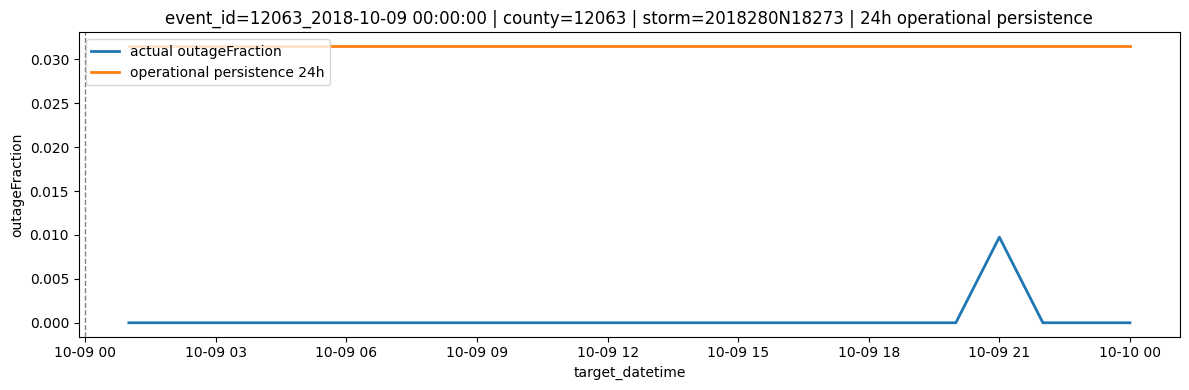

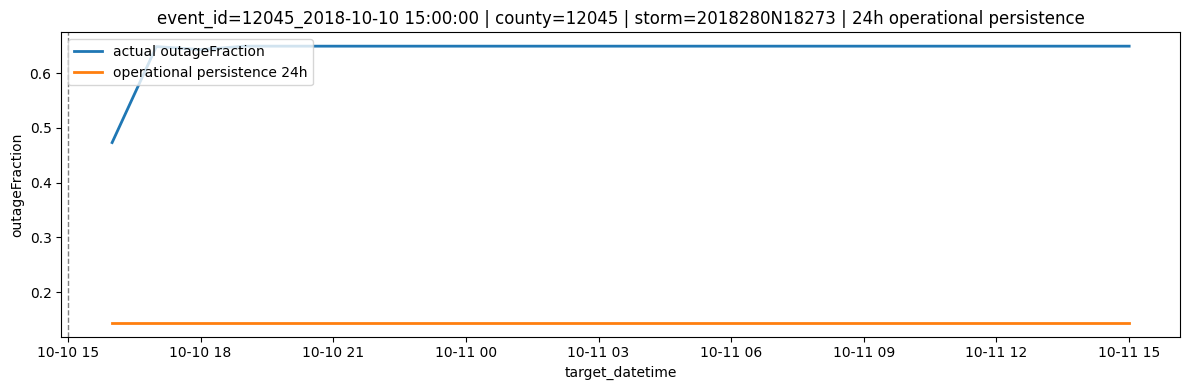

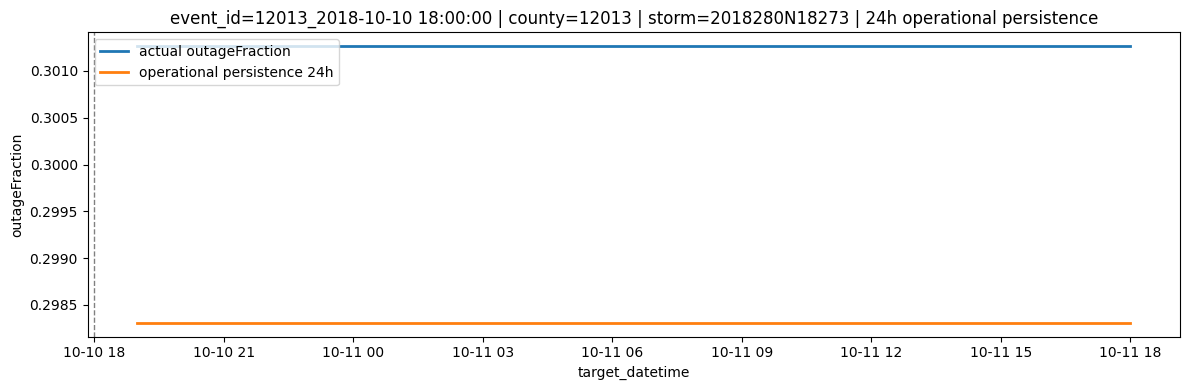

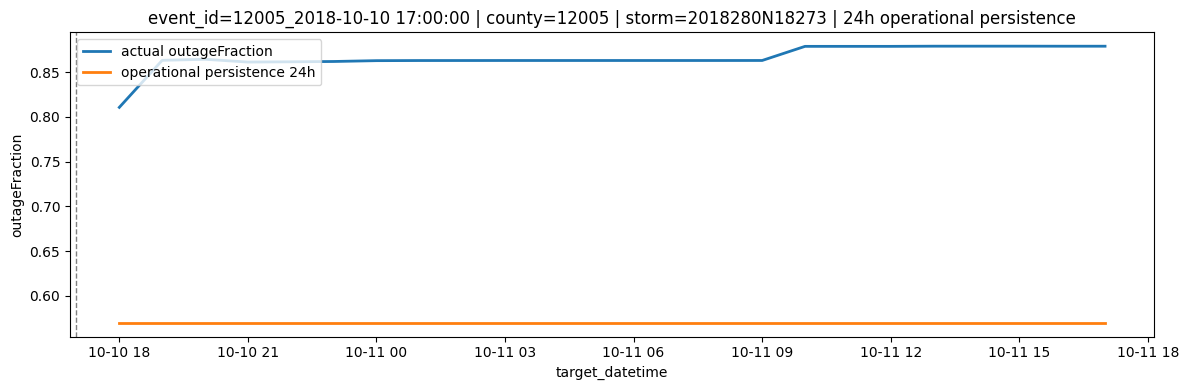


=== 48h operational persistence ===


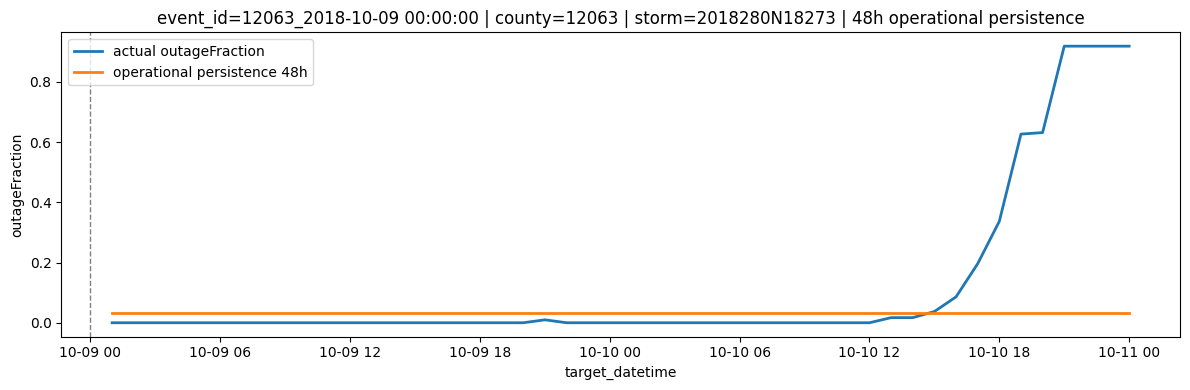

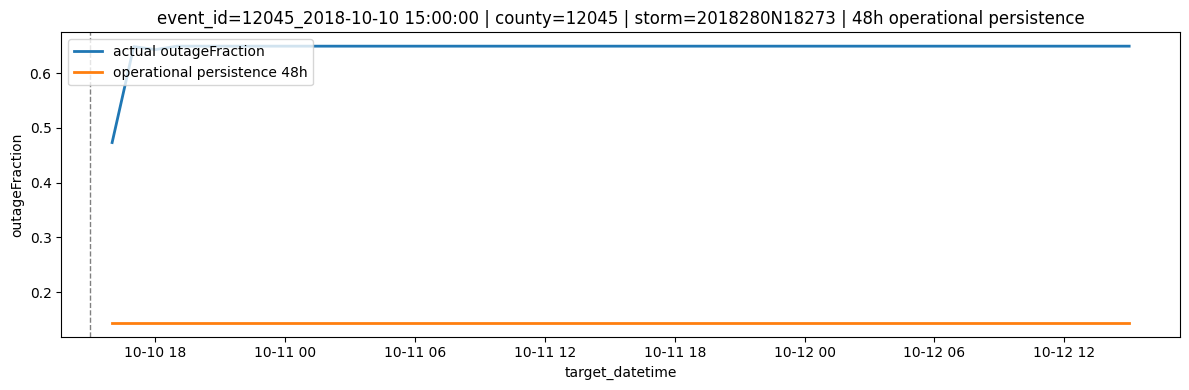

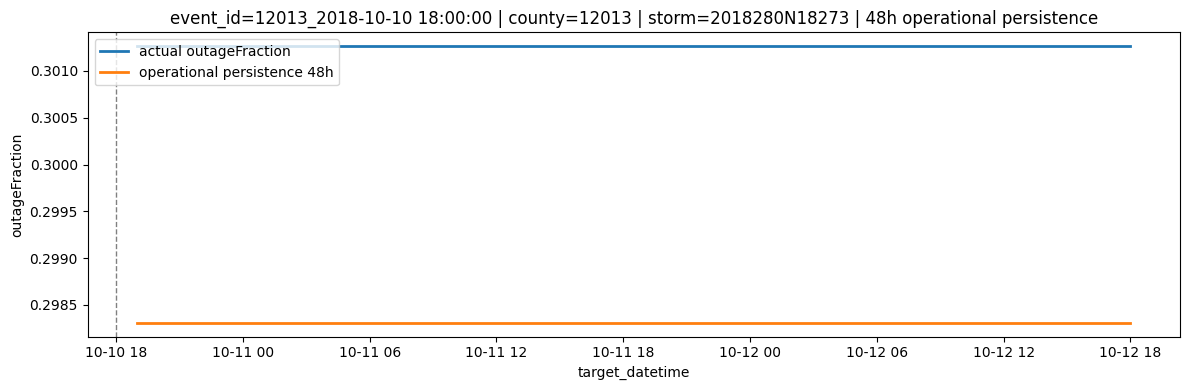

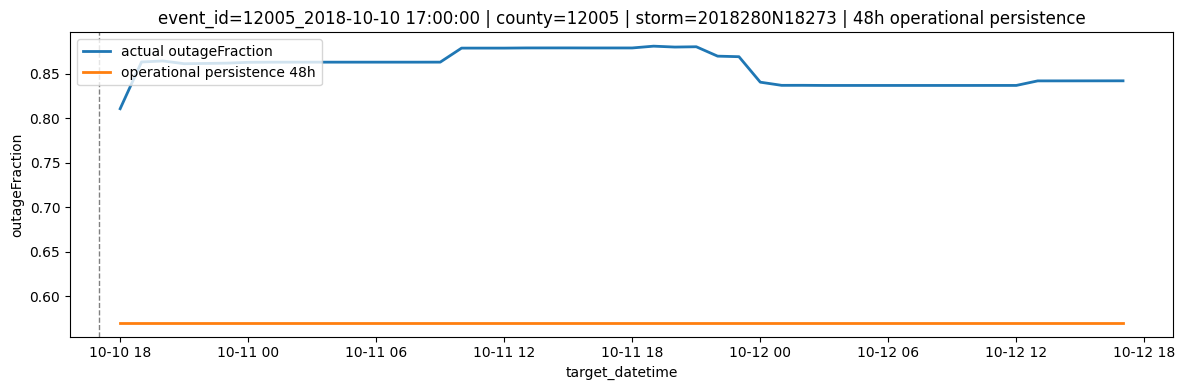


=== 72h operational persistence ===


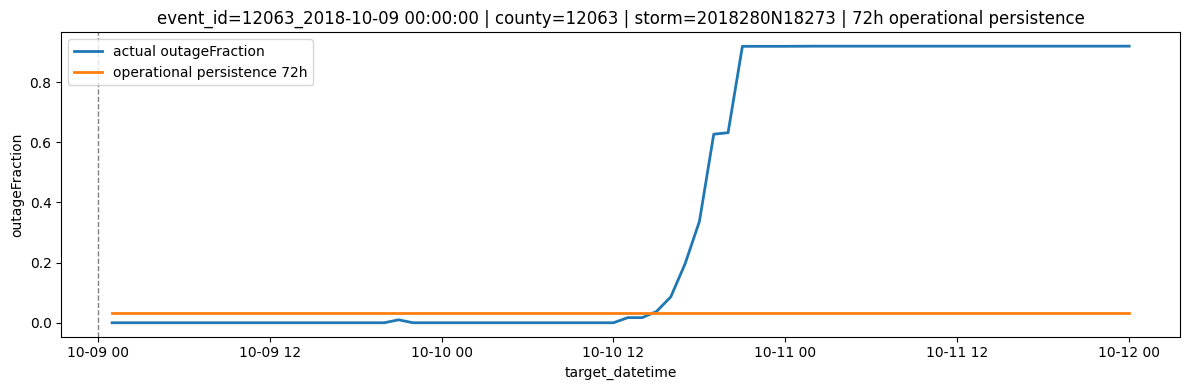

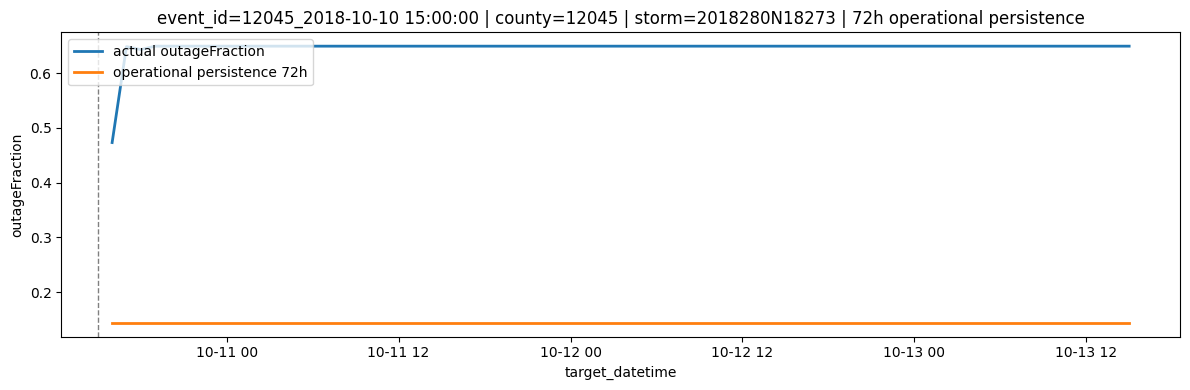

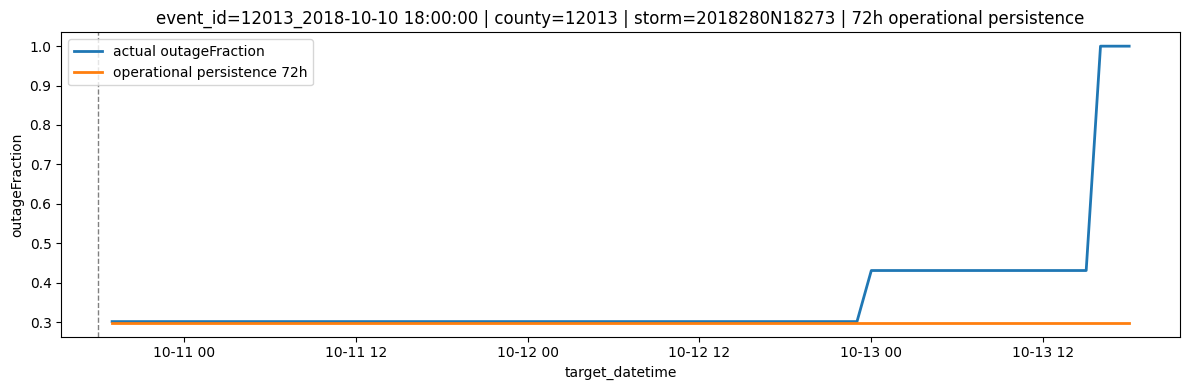

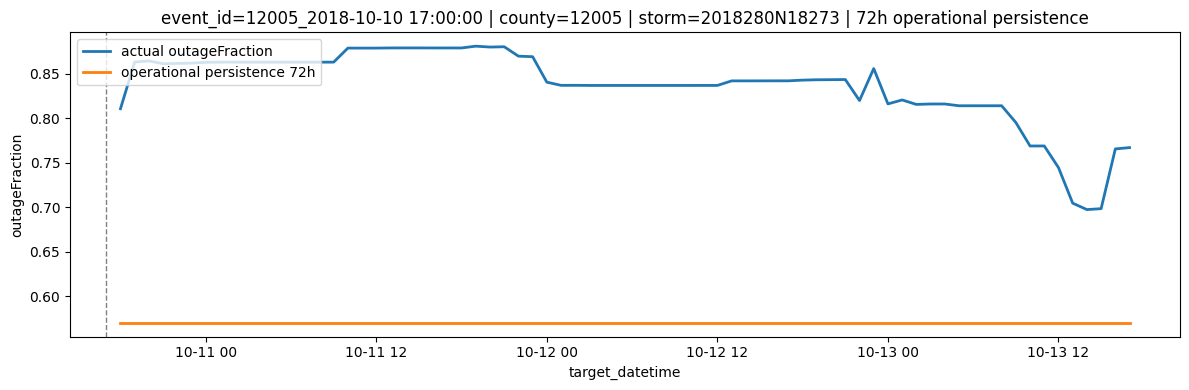

In [25]:
def plot_operational_persistence(df, title, horizon_hours):
    sub = df[df["forecast_horizon_hours"] == horizon_hours].copy()
    sub = sub.sort_values("target_datetime")
    sub = sub.dropna(subset=["y_actual", "y_pred"])

    if sub.empty:
        print(f"No valid rows for {title} at {horizon_hours}h horizon.")
        return

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(sub["target_datetime"], sub["y_actual"], label="actual outageFraction", linewidth=2)
    ax.plot(sub["target_datetime"], sub["y_pred"], label=f"operational persistence {horizon_hours}h", linewidth=2)
    ax.axvline(pd.to_datetime(sub["origin_datetime"].iloc[0]), linestyle="--", linewidth=1, color="gray")

    ax.set_title(f"{title} | {horizon_hours}h operational persistence")
    ax.set_xlabel("target_datetime")
    ax.set_ylabel("outageFraction")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


print(f"Plotting {len(sample_events)} events: {sample_events}")

for horizon_hours in FORECAST_HORIZONS:
    print(f"\n=== {horizon_hours}h operational persistence ===")
    for event_id in sample_events:
        sub = operational_persist_df[operational_persist_df["event_id"] == event_id].copy()
        if sub.empty:
            continue

        row = event_master[event_master["event_id"] == event_id].iloc[0]
        title = f"event_id={event_id} | county={row['CountyFIPS']} | storm={row['storm']}"
        plot_operational_persistence(sub, title, horizon_hours)

^ This doesn't look like what I was expecting, but it is correct; it's just showing the first N hours rather than the full event timeline

Now for creating the data that can be used to compare with TFT success in another notebook:

In [26]:
from pathlib import Path

DATA_TRANSIENTS_DIR = Path(r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients")
DATA_TRANSIENTS_DIR.mkdir(parents=True, exist_ok=True)

def _standardize_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for col in ["event_id", "CountyFIPS", "storm", "geoid", "county"]:
        if col in out.columns:
            out[col] = out[col].astype("string")

    if "CountyFIPS" in out.columns:
        out["CountyFIPS"] = out["CountyFIPS"].str.zfill(5)

    if "geoid" in out.columns:
        out["geoid"] = out["geoid"].str.zfill(5)

    if "datetime" in out.columns:
        out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce").dt.floor("h")

    if "event_start" in out.columns:
        out["event_start"] = pd.to_datetime(out["event_start"], errors="coerce")

    if "duration_hours" in out.columns:
        out["duration_hours"] = pd.to_numeric(out["duration_hours"], errors="coerce")

    return out

event_master = _standardize_frame(event_master)
coverage_df = _standardize_frame(coverage_df)
model_df = _standardize_frame(model_df)

event_master.to_parquet(DATA_TRANSIENTS_DIR / "florida_event_master.parquet", index=False)
coverage_df.to_parquet(DATA_TRANSIENTS_DIR / "florida_coverage.parquet", index=False)
model_df.to_parquet(DATA_TRANSIENTS_DIR / "florida_model_df.parquet", index=False)

print("Saved:")
print(DATA_TRANSIENTS_DIR / "florida_event_master.parquet")
print(DATA_TRANSIENTS_DIR / "florida_coverage.parquet")
print(DATA_TRANSIENTS_DIR / "florida_model_df.parquet")

Saved:
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_event_master.parquet
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_coverage.parquet
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_model_df.parquet


In [27]:
FORECAST_HORIZONS = [24, 48, 72]

def build_rolling_origin_persistence_eval(
    df: pd.DataFrame,
    horizons=FORECAST_HORIZONS,
    id_cols=("event_id", "CountyFIPS"),
    time_col="datetime",
    y_col="outageFraction",
    event_start_col="event_start",
):
    d = df.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce").dt.floor("h")
    d[event_start_col] = pd.to_datetime(d[event_start_col], errors="coerce")
    d = d.dropna(subset=[*id_cols, time_col, y_col, event_start_col]).sort_values(list(id_cols) + [time_col])

    rows = []

    for _, g in d.groupby(list(id_cols), sort=False):
        g = g.sort_values(time_col).drop_duplicates(subset=[time_col]).copy()
        if g.empty:
            continue

        event_id = g["event_id"].iloc[0]
        county_fips = g["CountyFIPS"].iloc[0]
        storm = g["storm"].iloc[0] if "storm" in g.columns else None
        event_start = g[event_start_col].iloc[0]
        duration_hours = g["duration_hours"].iloc[0] if "duration_hours" in g.columns else np.nan

        origins = g[g[time_col] >= event_start][[time_col, y_col]].copy()
        if origins.empty:
            continue
        origins = origins.rename(columns={time_col: "origin_datetime", y_col: "origin_value"})

        targets = g[[time_col, y_col]].copy().rename(columns={time_col: "target_datetime", y_col: "y_true"})

        meta = {
            "event_id": event_id,
            "CountyFIPS": county_fips,
            "storm": storm,
            "event_start": event_start,
            "duration_hours": duration_hours,
        }

        for h in horizons:
            tmp = targets.copy()
            tmp["origin_datetime"] = tmp["target_datetime"] - pd.Timedelta(hours=h)
            tmp = tmp.merge(origins, on="origin_datetime", how="inner")

            if tmp.empty:
                continue

            tmp["forecast_horizon_hours"] = h
            tmp["y_pred"] = tmp["origin_value"]
            tmp["hours_since_event_start_at_origin"] = (
                tmp["origin_datetime"] - event_start
            ).dt.total_seconds() / 3600.0

            for k, v in meta.items():
                tmp[k] = v

            rows.append(tmp)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    out = out.sort_values(["event_id", "forecast_horizon_hours", "origin_datetime", "target_datetime"]).reset_index(drop=True)
    return out

rolling_persist_eval_df = build_rolling_origin_persistence_eval(model_df)

print(f"Rolling-origin forecast rows: {len(rolling_persist_eval_df):,}")
display(rolling_persist_eval_df.head())

rolling_persist_eval_df.to_parquet(
    DATA_TRANSIENTS_DIR / "florida_rolling_persistence_eval.parquet",
    index=False,
)
print(DATA_TRANSIENTS_DIR / "florida_rolling_persistence_eval.parquet")

Rolling-origin forecast rows: 35,300


,target_datetime,y_true,origin_datetime,origin_value,forecast_horizon_hours,y_pred,hours_since_event_start_at_origin,event_id,CountyFIPS,storm,event_start,duration_hours
0,2017-09-12 03:00:00,0.362709,2017-09-11 03:00:00,0.083420,24,0.083420,0.0,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-11 03:00:00,134
1,2017-09-12 04:00:00,0.361133,2017-09-11 04:00:00,0.101754,24,0.101754,1.0,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-11 03:00:00,134
2,2017-09-12 05:00:00,0.370978,2017-09-11 05:00:00,0.147551,24,0.147551,2.0,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-11 03:00:00,134
3,2017-09-12 06:00:00,0.373706,2017-09-11 06:00:00,0.258554,24,0.258554,3.0,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-11 03:00:00,134
4,2017-09-12 07:00:00,0.358869,2017-09-11 07:00:00,0.400816,24,0.400816,4.0,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-11 03:00:00,134


C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_rolling_persistence_eval.parquet


In [28]:
def regression_metrics(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    valid = y_true.notna() & y_pred.notna()
    y_true = y_true[valid]
    y_pred = y_pred[valid]
    if len(y_true) == 0:
        return {"n": 0, "mae": np.nan, "rmse": np.nan}
    err = y_true - y_pred
    return {
        "n": int(len(y_true)),
        "mae": float(np.mean(np.abs(err))),
        "rmse": float(np.sqrt(np.mean(err ** 2))),
    }

overall_rows = []
event_rows = []

for h in FORECAST_HORIZONS:
    eval_h = rolling_persist_eval_df[rolling_persist_eval_df["forecast_horizon_hours"] == h].copy()
    if eval_h.empty:
        continue

    overall = regression_metrics(eval_h["y_true"], eval_h["y_pred"])
    overall["forecast_horizon_hours"] = h
    overall_rows.append(overall)

    event_metrics_h = (
        eval_h.groupby(["event_id", "CountyFIPS", "storm"], dropna=False)[["y_true", "y_pred"]]
        .apply(lambda x: pd.Series(regression_metrics(x["y_true"], x["y_pred"])))
        .reset_index()
    )
    event_metrics_h["forecast_horizon_hours"] = h
    event_rows.append(event_metrics_h)

operational_metrics_df = pd.DataFrame(overall_rows).sort_values("forecast_horizon_hours").reset_index(drop=True)
operational_event_metrics_df = pd.concat(event_rows, ignore_index=True).sort_values(
    ["forecast_horizon_hours", "mae", "rmse", "event_id"]
).reset_index(drop=True)

print("Overall rolling-origin persistence metrics:")
display(operational_metrics_df)

print("Event-level rolling-origin persistence metrics:")
display(operational_event_metrics_df.head(30))

operational_metrics_df.to_csv(DATA_TRANSIENTS_DIR / "florida_operational_persistence_metrics.csv", index=False)
operational_event_metrics_df.to_csv(DATA_TRANSIENTS_DIR / "florida_operational_persistence_event_metrics.csv", index=False)
print(DATA_TRANSIENTS_DIR / "florida_operational_persistence_metrics.csv")
print(DATA_TRANSIENTS_DIR / "florida_operational_persistence_event_metrics.csv")

Overall rolling-origin persistence metrics:


,n,mae,rmse,forecast_horizon_hours
0,13946,0.130528,0.195806,24
1,11645,0.213324,0.273092,48
2,9709,0.282697,0.339379,72


Event-level rolling-origin persistence metrics:


,event_id,CountyFIPS,storm,n,mae,rmse,forecast_horizon_hours
0,12051_2021-07-04 07:00:00,12051,2021182N09317,27.0,0.008083,0.024570,24
1,12063_2018-06-02 20:00:00,12063,2018146N19273,16.0,0.009255,0.017802,24
2,12063_2017-09-15 17:00:00,12063,2017242N16333,23.0,0.009846,0.023014,24
3,12049_2018-09-09 01:00:00,12049,2018246N22283,14.0,0.010595,0.026783,24
4,12013_2020-09-12 22:00:00,12013,2020256N25281,100.0,0.024168,0.046331,24
5,12029_2021-07-06 00:00:00,12029,2021182N09317,34.0,0.041431,0.084378,24
6,12059_2017-09-09 20:00:00,12059,2017242N16333,31.0,0.043541,0.130298,24
7,12005_2018-10-10 17:00:00,12005,2018280N18273,492.0,0.048609,0.067471,24
8,12075_2017-07-30 21:00:00,12075,2017212N28275,74.0,0.054170,0.213579,24
9,12119_2017-09-11 04:00:00,12119,2017242N16333,142.0,0.061229,0.073384,24


C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_operational_persistence_metrics.csv
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_operational_persistence_event_metrics.csv


In [29]:
def regression_metrics(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    valid = y_true.notna() & y_pred.notna()
    y_true = y_true[valid]
    y_pred = y_pred[valid]
    if len(y_true) == 0:
        return {"n": 0, "mae": np.nan, "rmse": np.nan}
    err = y_true - y_pred
    return {
        "n": int(len(y_true)),
        "mae": float(np.mean(np.abs(err))),
        "rmse": float(np.sqrt(np.mean(err ** 2))),
    }

overall_rows = []
event_rows = []

for h in FORECAST_HORIZONS:
    eval_h = rolling_persist_eval_df[rolling_persist_eval_df["forecast_horizon_hours"] == h].copy()
    if eval_h.empty:
        continue

    overall = regression_metrics(eval_h["y_true"], eval_h["y_pred"])
    overall["forecast_horizon_hours"] = h
    overall_rows.append(overall)

    event_metrics_h = (
        eval_h.groupby(["event_id", "CountyFIPS", "storm"], dropna=False)[["y_true", "y_pred"]]
        .apply(lambda x: pd.Series(regression_metrics(x["y_true"], x["y_pred"])))
        .reset_index()
    )
    event_metrics_h["forecast_horizon_hours"] = h
    event_rows.append(event_metrics_h)

operational_metrics_df = pd.DataFrame(overall_rows).sort_values("forecast_horizon_hours").reset_index(drop=True)
operational_event_metrics_df = pd.concat(event_rows, ignore_index=True).sort_values(
    ["forecast_horizon_hours", "mae", "rmse", "event_id"]
).reset_index(drop=True)

print("Overall rolling-origin persistence metrics:")
display(operational_metrics_df)

print("Event-level rolling-origin persistence metrics:")
display(operational_event_metrics_df.head(30))

operational_metrics_df.to_csv(DATA_TRANSIENTS_DIR / "florida_operational_persistence_metrics.csv", index=False)
operational_event_metrics_df.to_csv(DATA_TRANSIENTS_DIR / "florida_operational_persistence_event_metrics.csv", index=False)
print(DATA_TRANSIENTS_DIR / "florida_operational_persistence_metrics.csv")
print(DATA_TRANSIENTS_DIR / "florida_operational_persistence_event_metrics.csv")

Overall rolling-origin persistence metrics:


,n,mae,rmse,forecast_horizon_hours
0,13946,0.130528,0.195806,24
1,11645,0.213324,0.273092,48
2,9709,0.282697,0.339379,72


Event-level rolling-origin persistence metrics:


,event_id,CountyFIPS,storm,n,mae,rmse,forecast_horizon_hours
0,12051_2021-07-04 07:00:00,12051,2021182N09317,27.0,0.008083,0.024570,24
1,12063_2018-06-02 20:00:00,12063,2018146N19273,16.0,0.009255,0.017802,24
2,12063_2017-09-15 17:00:00,12063,2017242N16333,23.0,0.009846,0.023014,24
3,12049_2018-09-09 01:00:00,12049,2018246N22283,14.0,0.010595,0.026783,24
4,12013_2020-09-12 22:00:00,12013,2020256N25281,100.0,0.024168,0.046331,24
5,12029_2021-07-06 00:00:00,12029,2021182N09317,34.0,0.041431,0.084378,24
6,12059_2017-09-09 20:00:00,12059,2017242N16333,31.0,0.043541,0.130298,24
7,12005_2018-10-10 17:00:00,12005,2018280N18273,492.0,0.048609,0.067471,24
8,12075_2017-07-30 21:00:00,12075,2017212N28275,74.0,0.054170,0.213579,24
9,12119_2017-09-11 04:00:00,12119,2017242N16333,142.0,0.061229,0.073384,24


C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_operational_persistence_metrics.csv
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_operational_persistence_event_metrics.csv


Sample events: ['12063_2018-10-09 00:00:00', '12045_2018-10-10 15:00:00', '12013_2018-10-10 18:00:00', '12005_2018-10-10 17:00:00']


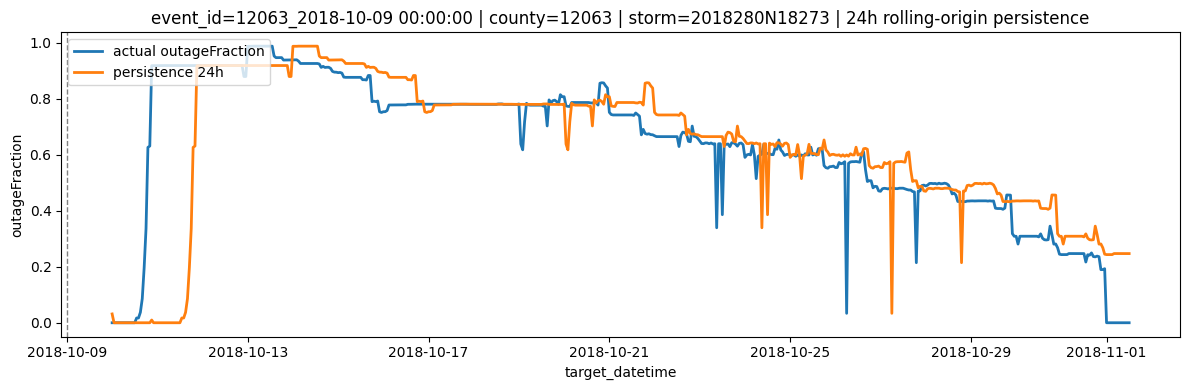

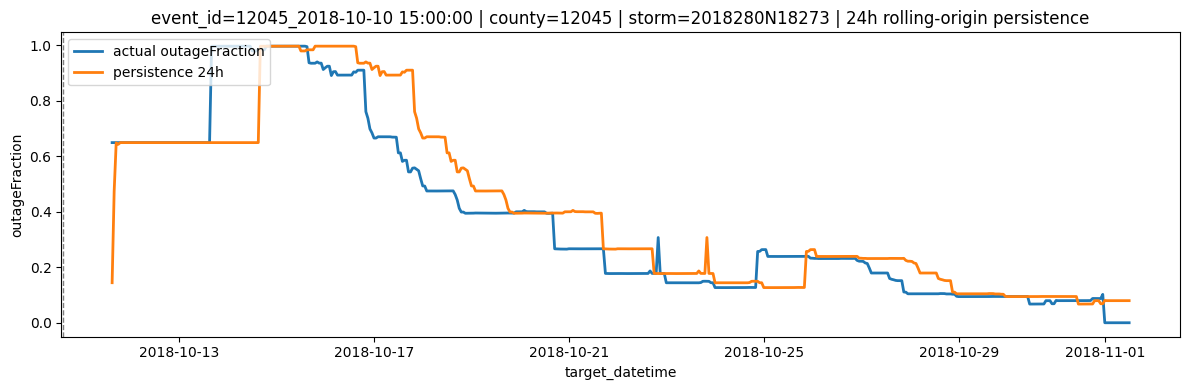

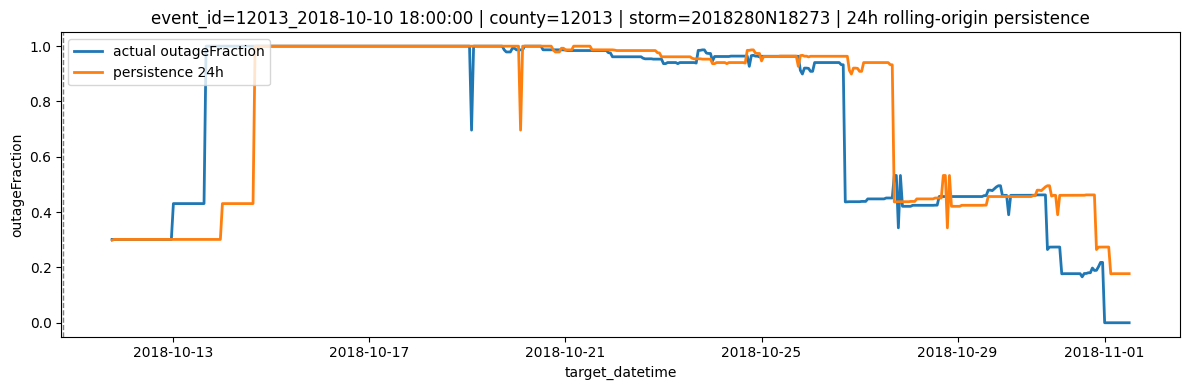

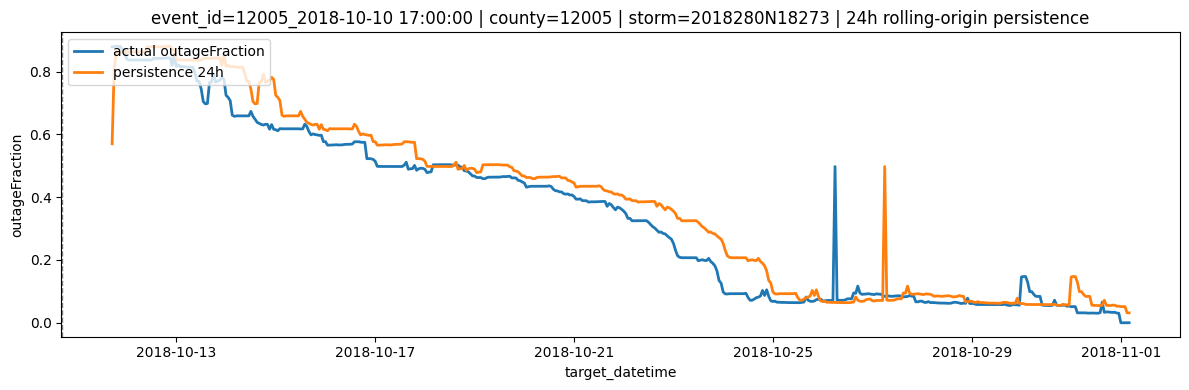

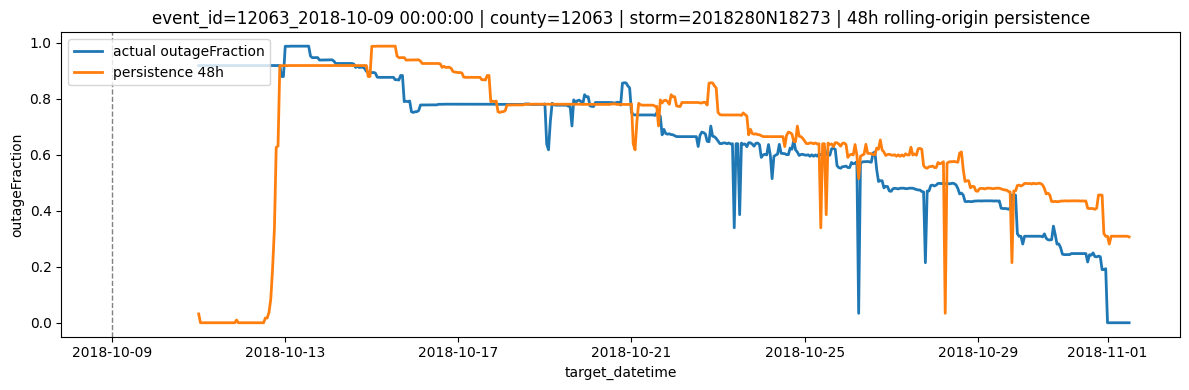

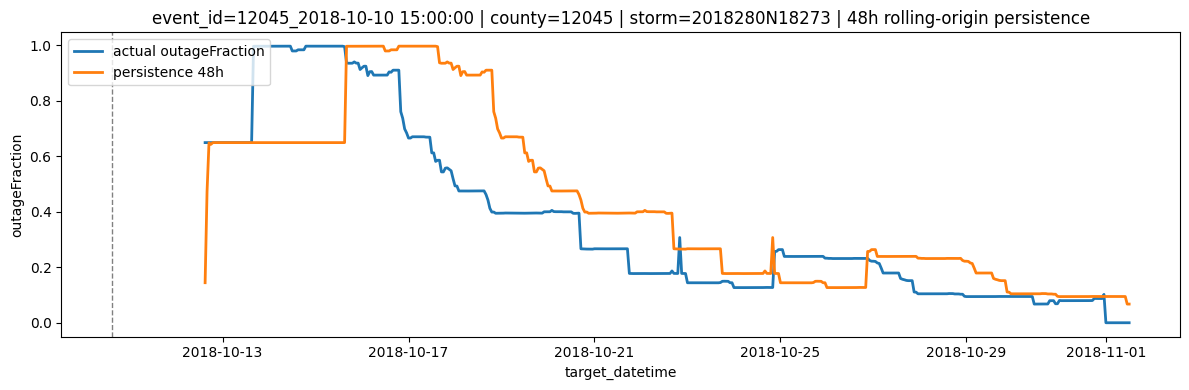

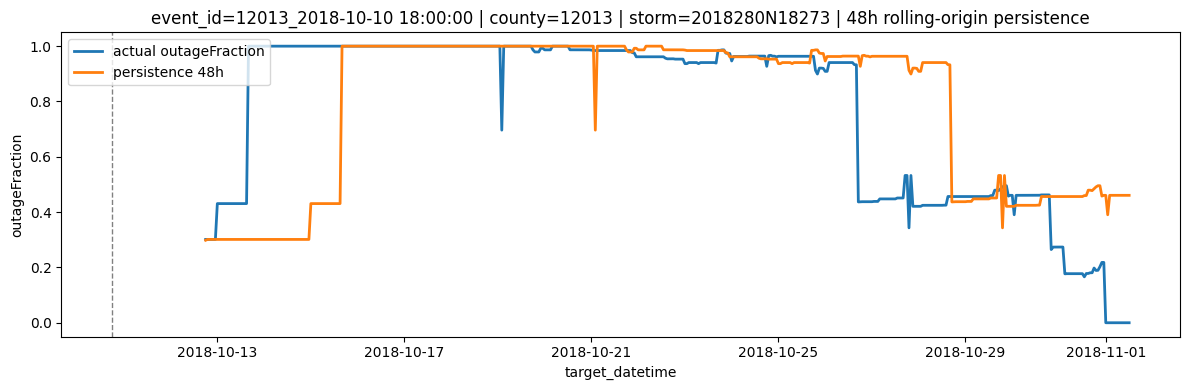

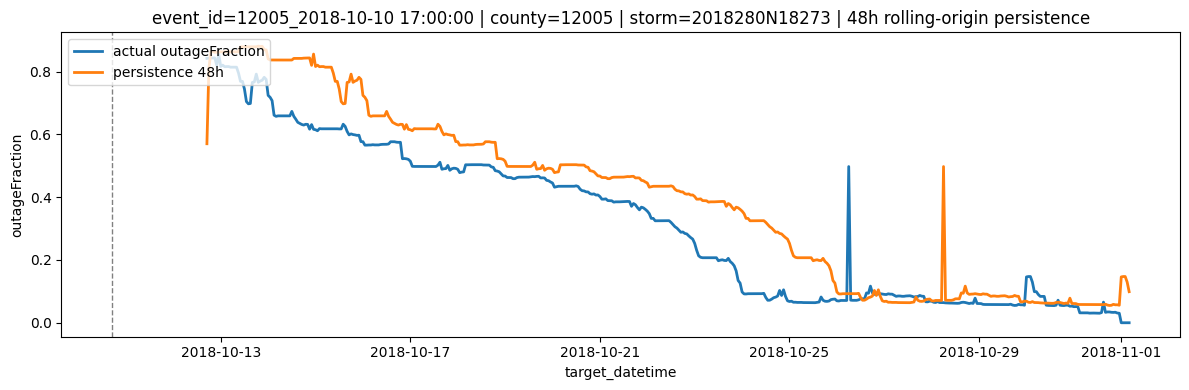

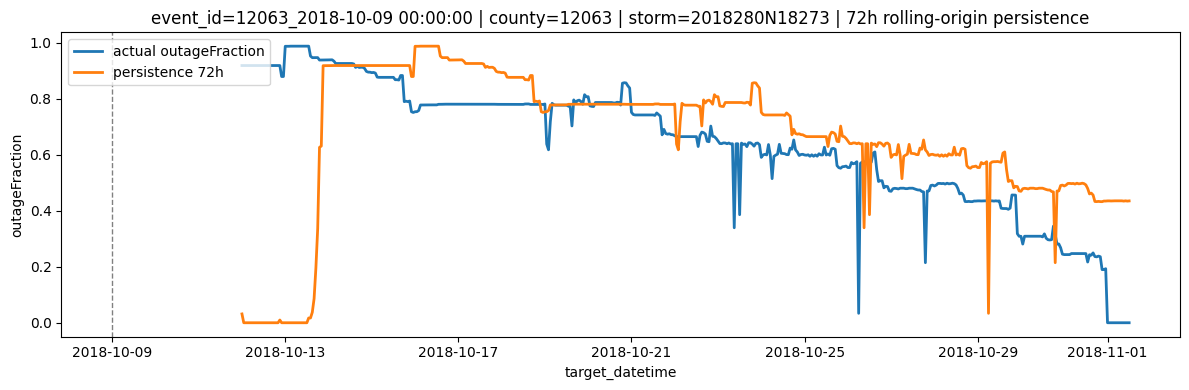

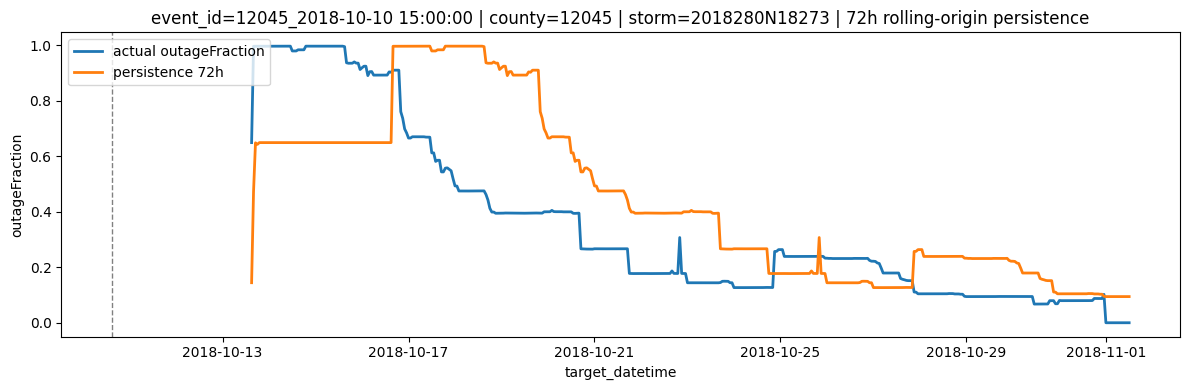

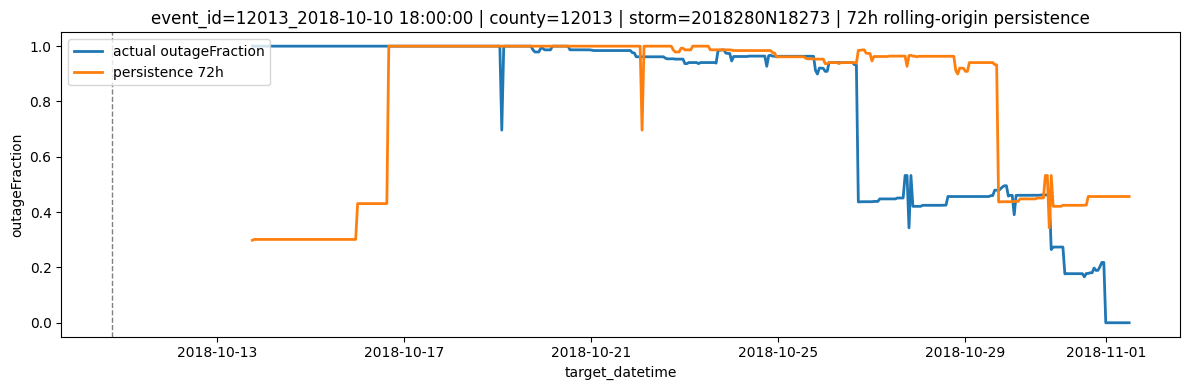

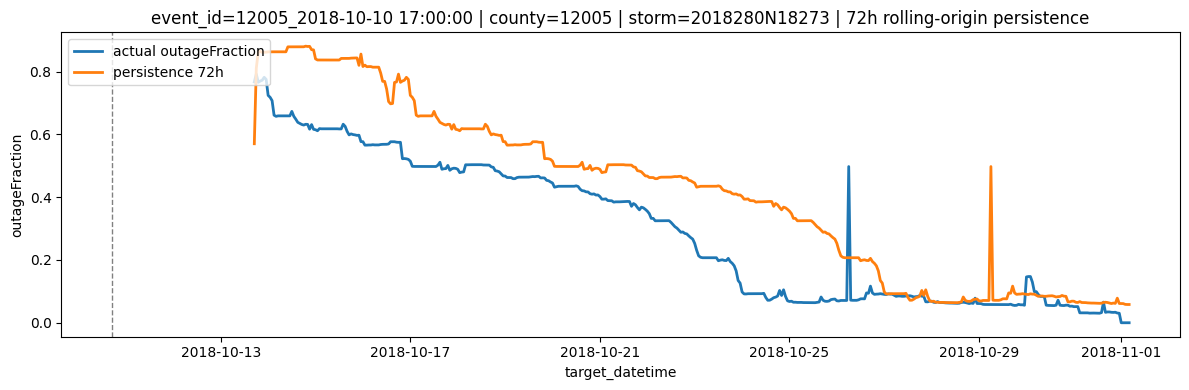

In [30]:
def plot_rolling_origin_persistence(df, event_id, horizon_hours):
    sub = df[
        (df["event_id"] == event_id) &
        (df["forecast_horizon_hours"] == horizon_hours)
    ].copy().sort_values("target_datetime")

    if sub.empty:
        print(f"No rows for event_id={event_id} at horizon={horizon_hours}h")
        return

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(sub["target_datetime"], sub["y_true"], label="actual outageFraction", linewidth=2)
    ax.plot(sub["target_datetime"], sub["y_pred"], label=f"persistence {horizon_hours}h", linewidth=2)
    ax.axvline(pd.to_datetime(sub["event_start"].iloc[0]), linestyle="--", linewidth=1, color="gray")
    ax.set_title(f"event_id={event_id} | county={sub['CountyFIPS'].iloc[0]} | storm={sub['storm'].iloc[0]} | {horizon_hours}h rolling-origin persistence")
    ax.set_xlabel("target_datetime")
    ax.set_ylabel("outageFraction")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

sample_events = (
    coverage_df.sort_values(["merged_rows", "event_start"], ascending=[False, True])
    .head(4)["event_id"]
    .tolist()
)

print(f"Sample events: {sample_events}")

for h in FORECAST_HORIZONS:
    for event_id in sample_events:
        plot_rolling_origin_persistence(rolling_persist_eval_df, event_id, h)